In [1]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image
from cv_bridge import CvBridge
import cv2

from PIL import Image as PILImage
import numpy as np
from IPython.display import display, Image as IPImage
import io


In [2]:
class ImageSubscriber(Node):
    def __init__(self):
        super().__init__('image_subscriber_2')
        self.subscription = self.create_subscription(
            Image,
            '/camera/camera/color/image_raw',
            self.rgb_listener_callback,
            10)
        self.depth_subscription = self.create_subscription(
            Image,
            '/camera/camera/depth/image_rect_raw',
            self.depth_listener_callback,
            10)
        
        self.br = CvBridge()

        self.current_rgb_frame = None
        self.current_depth_frame = None
        
    def rgb_listener_callback(self, data):
        self.get_logger().info('Receiving video frame')
        # As pointed in comments below modify the following to use bgr encoding
        frame = self.br.imgmsg_to_cv2(data, desired_encoding='bgr8')
        self.current_rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 

    def depth_listener_callback(self, data):
        self.get_logger().info('Receiving depth frame')

        cv_image = self.br.imgmsg_to_cv2(data, "32FC1")
        self.current_depth_frame = np.expand_dims(cv_image.astype(int), -1).shape

    def get_image(self):
        return self.current_rgb_frame

    def get_depth(self):
        return self.current_depth_frame



In [3]:
rclpy.init()

In [4]:
image_subscriber = ImageSubscriber()

In [11]:
rclpy.spin_once(image_subscriber, timeout_sec=0.1) 
rclpy.spin_once(image_subscriber, timeout_sec=0.1) 


[INFO] [1764688999.165560676] [image_subscriber_2]: Receiving video frame
[INFO] [1764688999.172752478] [image_subscriber_2]: Receiving depth frame


In [12]:
image = image_subscriber.get_image()
d_image = image_subscriber.get_depth()

In [13]:
type(d_image)
np.expand_dims(d_image, -1).shape

(3, 1)

In [14]:
def show_image(image):
    # Convert to PIL Image
    pil_img = PILImage.fromarray(image)
    
    # Convert PIL image → PNG bytes
    buf = io.BytesIO()
    pil_img.save(buf, format='PNG')
    buf.seek(0)
    
    # Display
    display(IPImage(data=buf.getvalue()))

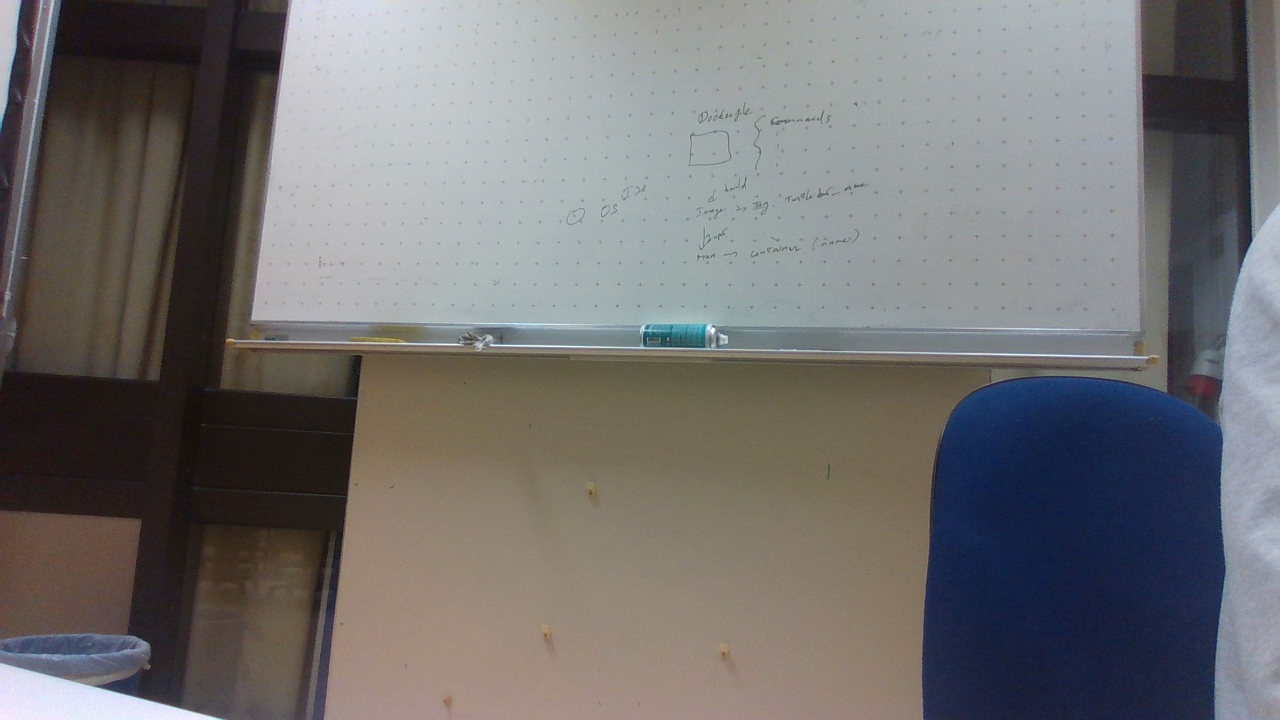

In [15]:
show_image(image)

In [18]:
show_image(d_image)

AttributeError: 'tuple' object has no attribute '__array_interface__'

In [17]:
image_subscriber.destroy_node()
rclpy.shutdown()